# Quantium Virtual Internship 
## Experimentation & Uplift Testing

**Author:** Your Name  
**Program:** Quantium Data Analytics — Forage  
**Objective:** Evaluate the performance of trial store layouts (stores 77, 86, 88) against matched control stores, and provide a data-driven recommendation to the Category Manager.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (13, 5)

In [3]:
data = pd.read_csv('../Data/QVI_data.csv', parse_dates=['DATE'])
print(f'Rows: {len(data):,}  |  Columns: {data.shape[1]}')
data.head()

Rows: 264,834  |  Columns: 12


,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream


#### BUILD MONTHLY STORE METRICS

In [4]:

data['YEARMONTH'] = data['DATE'].dt.year * 100 + data['DATE'].dt.month


measure_over_time = (
    data.groupby(['STORE_NBR', 'YEARMONTH'])
    .agg(
        totSales        = ('TOT_SALES',       'sum'),
        nCustomers      = ('LYLTY_CARD_NBR',  'nunique'),
        nTxn            = ('TXN_ID',           'nunique'),
    )
    .reset_index()
)
measure_over_time['nTxnPerCust']      = measure_over_time['nTxn']      / measure_over_time['nCustomers']
measure_over_time['nChipsPerTxn']     = (
    data.groupby(['STORE_NBR','YEARMONTH'])['PROD_QTY'].sum().values
    / measure_over_time['nTxn'].values
)
measure_over_time['avgPricePerUnit']  = (
    measure_over_time['totSales'] / 
    data.groupby(['STORE_NBR','YEARMONTH'])['PROD_QTY'].sum().values
)


pre_trial = measure_over_time[measure_over_time['YEARMONTH'] < 201902]
stores_full_obs = (
    pre_trial.groupby('STORE_NBR')['YEARMONTH'].count()
    .pipe(lambda s: s[s == 7].index.tolist())
)
pre_trial_measures = pre_trial[pre_trial['STORE_NBR'].isin(stores_full_obs)].copy()

print(f'Total stores with full pre-trial data: {len(stores_full_obs)}')
measure_over_time.head()

Total stores with full pre-trial data: 260


,STORE_NBR,YEARMONTH,totSales,nCustomers,nTxn,nTxnPerCust,nChipsPerTxn,avgPricePerUnit
0,1,201807,206.9,49,52,1.061224,1.192308,3.337097
1,1,201808,176.1,42,43,1.023810,1.255814,3.261111
2,1,201809,278.8,59,62,1.050847,1.209677,3.717333
3,1,201810,188.1,44,45,1.022727,1.288889,3.243103
4,1,201811,192.6,46,47,1.021739,1.212766,3.378947


#### CONTROL STORE SELCTION FUNCTIONS

In [8]:
def calculate_correlation(input_table, metric_col, trial_store):
    """
    For each control store candidate, calculate the Pearson correlation
    of 'metric_col' over time compared to the trial store.
    Returns a DataFrame with Store1, Store2, corr_measure.
    """
    trial_series = (
        input_table[input_table['STORE_NBR'] == trial_store]
        .set_index('YEARMONTH')[metric_col]
    )
    results = []
    for store in input_table['STORE_NBR'].unique():
        if store == trial_store:
            continue
        ctrl_series = (
            input_table[input_table['STORE_NBR'] == store]
            .set_index('YEARMONTH')[metric_col]
        )
        
        combined = pd.concat([trial_series, ctrl_series], axis=1, join='inner')
        combined.columns = ['trial', 'control']
        if len(combined) < 2:
            continue
        corr, _ = stats.pearsonr(combined['trial'], combined['control'])
        results.append({'Store1': trial_store, 'Store2': store, 'corr_measure': corr})
    return pd.DataFrame(results)


def calculate_magnitude_distance(input_table, metric_col, trial_store):
    """
    For each control store candidate, calculate a normalised magnitude
    distance (0-1, where 1 = most similar) of 'metric_col' vs trial store.
    Returns a DataFrame with Store1, Store2, mag_measure.
    """
    trial_data = input_table[input_table['STORE_NBR'] == trial_store][['YEARMONTH', metric_col]]
    results = []
    for store in input_table['STORE_NBR'].unique():
        if store == trial_store:
            continue
        ctrl_data = input_table[input_table['STORE_NBR'] == store][['YEARMONTH', metric_col]]
        merged = trial_data.merge(ctrl_data, on='YEARMONTH', suffixes=('_trial','_ctrl'))
        if merged.empty:
            continue
        merged['abs_diff'] = (merged[f'{metric_col}_trial'] - merged[f'{metric_col}_ctrl']).abs()
        results.append({'Store1': trial_store, 'Store2': store,
                        'avg_abs_diff': merged['abs_diff'].mean()})
    
    dist_df = pd.DataFrame(results)
    min_d   = dist_df['avg_abs_diff'].min()
    max_d   = dist_df['avg_abs_diff'].max()
    dist_df['mag_measure'] = 1 - (dist_df['avg_abs_diff'] - min_d) / (max_d - min_d + 1e-10)
    return dist_df[['Store1','Store2','mag_measure']]


def get_control_store(trial_store, pre_trial_data, corr_weight=0.5):
    """
    Combines correlation + magnitude scores for totSales and nCustomers
    to select the best-matching control store for a given trial store.
    Returns (control_store_number, score_df).
    """
    # Sales scores
    corr_sales = calculate_correlation(pre_trial_data, 'totSales', trial_store)
    mag_sales  = calculate_magnitude_distance(pre_trial_data, 'totSales', trial_store)
    score_sales = corr_sales.merge(mag_sales, on=['Store1','Store2'])
    score_sales['scoreNSales'] = corr_weight * score_sales['corr_measure'] + (1-corr_weight) * score_sales['mag_measure']

    # Customer scores
    corr_cust = calculate_correlation(pre_trial_data, 'nCustomers', trial_store)
    mag_cust  = calculate_magnitude_distance(pre_trial_data, 'nCustomers', trial_store)
    score_cust = corr_cust.merge(mag_cust, on=['Store1','Store2'])
    score_cust['scoreNCust'] = corr_weight * score_cust['corr_measure'] + (1-corr_weight) * score_cust['mag_measure']

    # Combined final score
    score_control = score_sales[['Store1','Store2','scoreNSales']].merge(
        score_cust[['Store1','Store2','scoreNCust']], on=['Store1','Store2']
    )
    score_control['finalScore'] = 0.5 * score_control['scoreNSales'] + 0.5 * score_control['scoreNCust']
    score_control = score_control.sort_values('finalScore', ascending=False).reset_index(drop=True)

    # Best control = highest score (excluding the trial store itself)
    best = score_control[score_control['Store2'] != trial_store].iloc[0]['Store2']
    return int(best), score_control

print('Functions defined ✓') 

Functions defined ✓


#### TRAIL ASSESSMENT FUNCTION

In [6]:
def assess_trial(trial_store, control_store, measure_df, metric, metric_label, fig_prefix):
    """
    Full trial assessment pipeline for one metric.
    
    Parameters
    ----------
    trial_store   : int   — store number of trial store
    control_store : int   — store number of matched control store
    measure_df    : DataFrame — full monthly store metrics table
    metric        : str   — column name of the metric (e.g. 'totSales')
    metric_label  : str   — human-readable label for y-axis
    fig_prefix    : str   — prefix for saved figure filename
    """
    TRIAL_START = 201902
    TRIAL_END   = 201904
    DOF         = 7   
    t_critical  = stats.t.ppf(0.95, df=DOF)  

    trial_df   = measure_df[measure_df['STORE_NBR'] == trial_store][['YEARMONTH', metric]].copy()
    control_df = measure_df[measure_df['STORE_NBR'] == control_store][['YEARMONTH', metric]].copy()

    
    trial_pretrial   = trial_df[trial_df['YEARMONTH'] < TRIAL_START][metric].sum()
    control_pretrial = control_df[control_df['YEARMONTH'] < TRIAL_START][metric].sum()
    scaling_factor   = trial_pretrial / control_pretrial

    control_df['scaled'] = control_df[metric] * scaling_factor

    
    pct_diff = trial_df.merge(control_df[['YEARMONTH','scaled']], on='YEARMONTH')
    pct_diff['pct_diff'] = (pct_diff[metric] - pct_diff['scaled']).abs() / pct_diff['scaled']

    std_dev = pct_diff[pct_diff['YEARMONTH'] < TRIAL_START]['pct_diff'].std()

    
    trial_months = pct_diff[(pct_diff['YEARMONTH'] >= TRIAL_START) & 
                             (pct_diff['YEARMONTH'] <= TRIAL_END)].copy()
    trial_months['t_value'] = trial_months['pct_diff'] / std_dev
    trial_months['significant'] = trial_months['t_value'] > t_critical

    print(f"\n{'═'*60}")
    print(f"  Trial Store {trial_store}  ←→  Control Store {control_store}")
    print(f"  Metric: {metric_label}")
    print(f"  Scaling factor: {scaling_factor:.4f}")
    print(f"  Pre-trial std dev of % diff: {std_dev:.4f}")
    print(f"  T-critical (95%, df={DOF}): {t_critical:.4f}")
    print(f"{'─'*60}")
    print(f"  {'Month':<12} {'% Diff':>10} {'T-Value':>10} {'Significant?':>14}")
    for _, row in trial_months.iterrows():
        flag = 'YES' if row['significant'] else 'NO'
        print(f"  {str(int(row['YEARMONTH'])):<12} {row['pct_diff']:>10.4f} {row['t_value']:>10.4f} {flag:>14}")
    print(f"{'═'*60}")

    
    plot_trial   = trial_df.copy()
    plot_trial['store_type'] = 'Trial'
    plot_trial.rename(columns={metric: 'value'}, inplace=True)

    plot_control = control_df[['YEARMONTH','scaled']].copy()
    plot_control['store_type'] = 'Control'
    plot_control.rename(columns={'scaled': 'value'}, inplace=True)

    plot_ctrl_95 = plot_control.copy()
    plot_ctrl_95['value']      = plot_ctrl_95['value'] * (1 + std_dev * 2)
    plot_ctrl_95['store_type'] = 'Control 95th % CI'

    plot_ctrl_05 = plot_control.copy()
    plot_ctrl_05['value']      = plot_ctrl_05['value'] * (1 - std_dev * 2)
    plot_ctrl_05['store_type'] = 'Control 5th % CI'

    all_plot = pd.concat([plot_trial, plot_control, plot_ctrl_95, plot_ctrl_05])
    all_plot['Date'] = pd.to_datetime(
        all_plot['YEARMONTH'].astype(str) + '01', format='%Y%m%d'
    )

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(13, 5))

    color_map = {
        'Trial'             : '#e74c3c',
        'Control'           : '#2980b9',
        'Control 95th % CI' : '#95a5a6',
        'Control 5th % CI'  : '#95a5a6',
    }
    style_map = {
        'Trial'             : '-',
        'Control'           : '-',
        'Control 95th % CI' : '--',
        'Control 5th % CI'  : '--',
    }

    for stype, grp in all_plot.groupby('store_type'):
        grp = grp.sort_values('Date')
        ax.plot(grp['Date'], grp['value'],
                label=stype,
                color=color_map[stype],
                linestyle=style_map[stype],
                linewidth=2 if 'Trial' in stype or stype == 'Control' else 1.2)

    # Shade trial period
    trial_start_dt = pd.to_datetime('2019-02-01')
    trial_end_dt   = pd.to_datetime('2019-04-30')
    ax.axvspan(trial_start_dt, trial_end_dt, alpha=0.12, color='gold', label='Trial Period')

    ax.set_title(f'{metric_label} — Trial Store {trial_store} vs Control Store {control_store}',
                 fontweight='bold', fontsize=13)
    ax.set_xlabel('Month')
    ax.set_ylabel(metric_label)
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
    plt.xticks(rotation=30, ha='right')
    ax.legend(loc='upper left', fontsize=9)
    plt.tight_layout()

    fname = f'{fig_prefix}_store{trial_store}_{metric}.png'
    plt.savefig(fname, bbox_inches='tight')
    plt.show()
    print(f'Figure saved: {fname}')
    return trial_months

print('assess_trial() function defined ✓')

assess_trial() function defined ✓


In [7]:
def plot_pre_trial_check(trial_store, control_store, measure_df, metric, metric_label):
    """
    Visualise pre-trial trends to visually verify control store similarity.
    """
    df = measure_df.copy()
    df['store_type'] = df['STORE_NBR'].apply(
        lambda x: 'Trial' if x == trial_store
        else ('Control' if x == control_store else 'Other Stores')
    )
    avg = df[df['YEARMONTH'] < 201903].groupby(['YEARMONTH','store_type'])[metric].mean().reset_index()
    avg['Date'] = pd.to_datetime(avg['YEARMONTH'].astype(str) + '01', format='%Y%m%d')

    fig, ax = plt.subplots(figsize=(12, 5))
    colors = {'Trial': '#e74c3c', 'Control': '#2980b9', 'Other Stores': '#bdc3c7'}
    widths = {'Trial': 2.5, 'Control': 2.5, 'Other Stores': 0.7}
    for stype, grp in avg.groupby('store_type'):
        grp = grp.sort_values('Date')
        ax.plot(grp['Date'], grp[metric],
                label=stype, color=colors[stype], linewidth=widths[stype],
                alpha=0.4 if stype == 'Other Stores' else 1.0)
    ax.set_title(f'Pre-Trial Check: {metric_label} — Store {trial_store} vs Store {control_store}',
                 fontweight='bold')
    ax.set_xlabel('Month'); ax.set_ylabel(metric_label)
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
    plt.xticks(rotation=30, ha='right')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'pretrial_store{trial_store}_{metric}.png', bbox_inches='tight')
    plt.show()

print('plot_pre_trial_check() function defined ✓')

plot_pre_trial_check() function defined ✓


#### TRAIL STORE 77

#### 4.1 FIND ONTROL STORE FOR STORE 77

In [9]:
trial_store_77 = 77
control_77, scores_77 = get_control_store(trial_store_77, pre_trial_measures)

print(f' Best control store for Trial Store 77 → Store {control_77}')
print('\nTop 5 matching stores:')
print(scores_77.head())

✅ Best control store for Trial Store 77 → Store 233

Top 5 matching stores:
   Store1  Store2  scoreNSales  scoreNCust  finalScore
0      77     233     0.951887    0.995179    0.973533
1      77      41     0.880579    0.912850    0.896715
2      77      17     0.864397    0.858222    0.861309
3      77     254     0.754326    0.928783    0.841555
4      77     115     0.815929    0.844780    0.830355


#### VISUAL PRE TRAIL CHECK - STORE 77

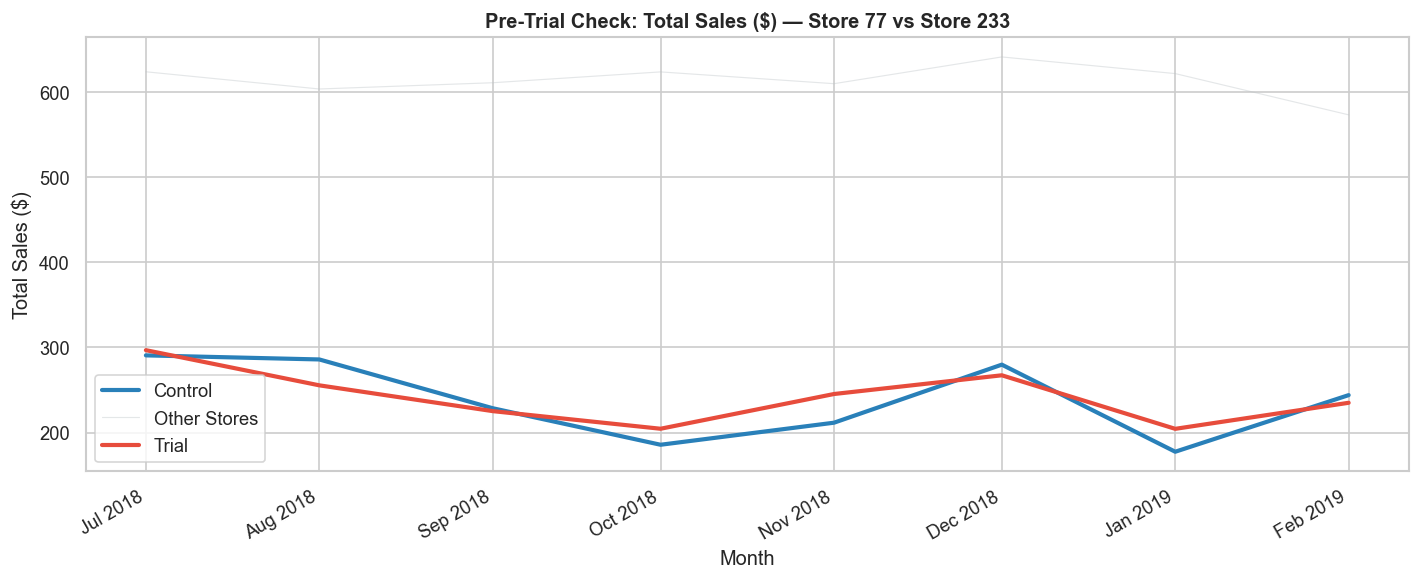

In [10]:
plot_pre_trial_check(trial_store_77, control_77, measure_over_time, 'totSales', 'Total Sales ($)')

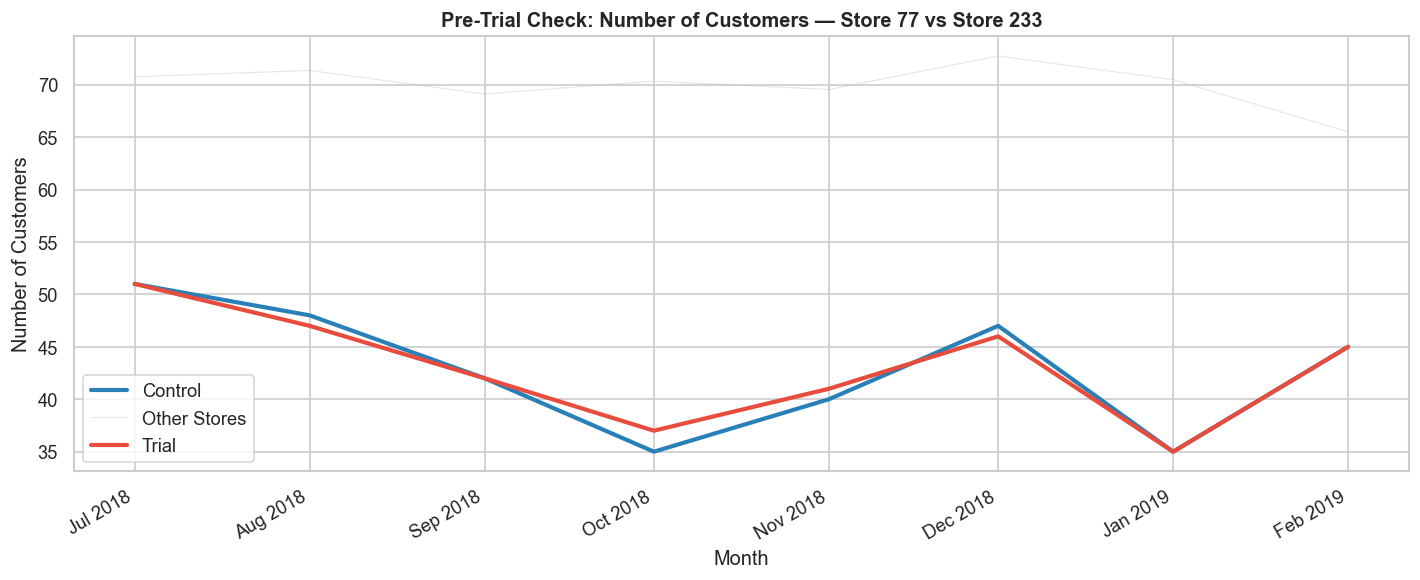

In [11]:
plot_pre_trial_check(trial_store_77, control_77, measure_over_time, 'nCustomers', 'Number of Customers')

#### 4.3 TRAIL ASSESMENT - STORE 77 (TOTAL SALES)


════════════════════════════════════════════════════════════
  Trial Store 77  ←→  Control Store 233
  Metric: Total Sales ($)
  Scaling factor: 1.0236
  Pre-trial std dev of % diff: 0.0499
  T-critical (95%, df=7): 1.8946
────────────────────────────────────────────────────────────
  Month            % Diff    T-Value   Significant?
  201902           0.0591     1.1835           ❌ NO
  201903           0.3665     7.3391          ✅ YES
  201904           0.6231    12.4764          ✅ YES
════════════════════════════════════════════════════════════


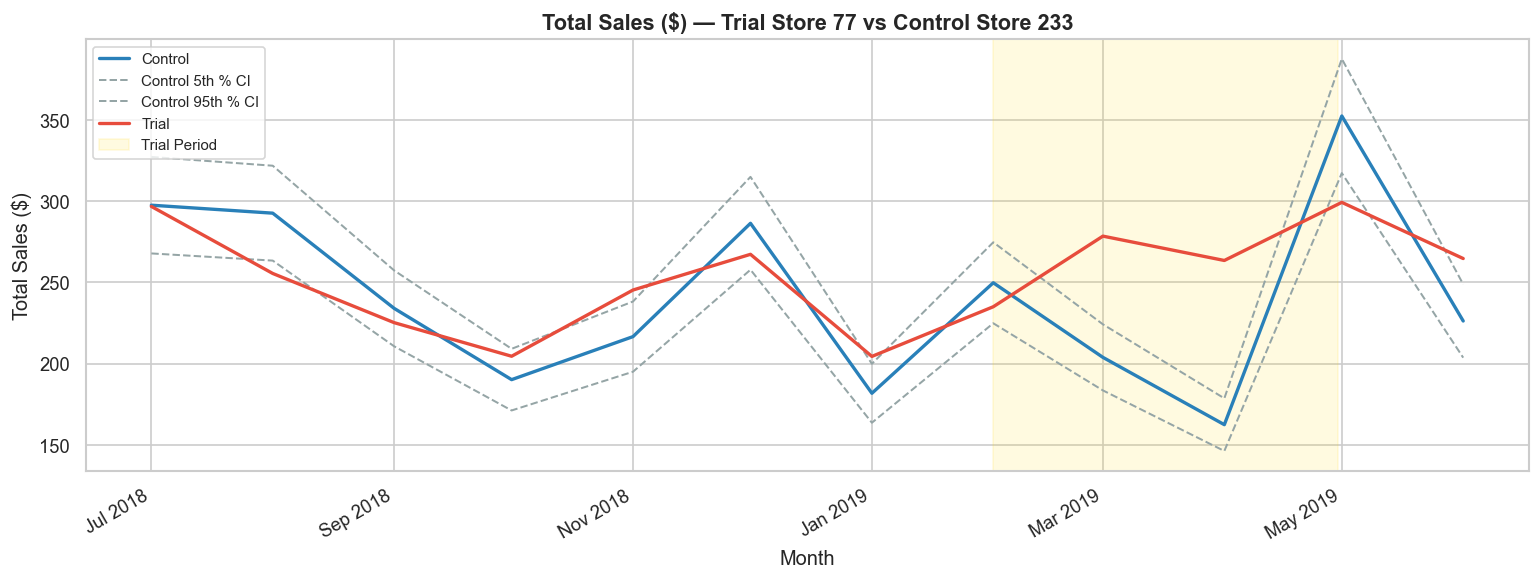

Figure saved: trial_assessment_store77_totSales.png


In [12]:
result_77_sales = assess_trial(
    trial_store   = trial_store_77,
    control_store = control_77,
    measure_df    = measure_over_time,
    metric        = 'totSales',
    metric_label  = 'Total Sales ($)',
    fig_prefix    = 'trial_assessment'
)

#### TRAIL ASSESMENT - STORE 77 (NO. OF CUSTOMERS)


════════════════════════════════════════════════════════════
  Trial Store 77  ←→  Control Store 233
  Metric: Number of Customers
  Scaling factor: 1.0034
  Pre-trial std dev of % diff: 0.0182
  T-critical (95%, df=7): 1.8946
────────────────────────────────────────────────────────────
  Month            % Diff    T-Value   Significant?
  201902           0.0033     0.1834           ❌ NO
  201903           0.2458    13.4764          ✅ YES
  201904           0.5614    30.7787          ✅ YES
════════════════════════════════════════════════════════════


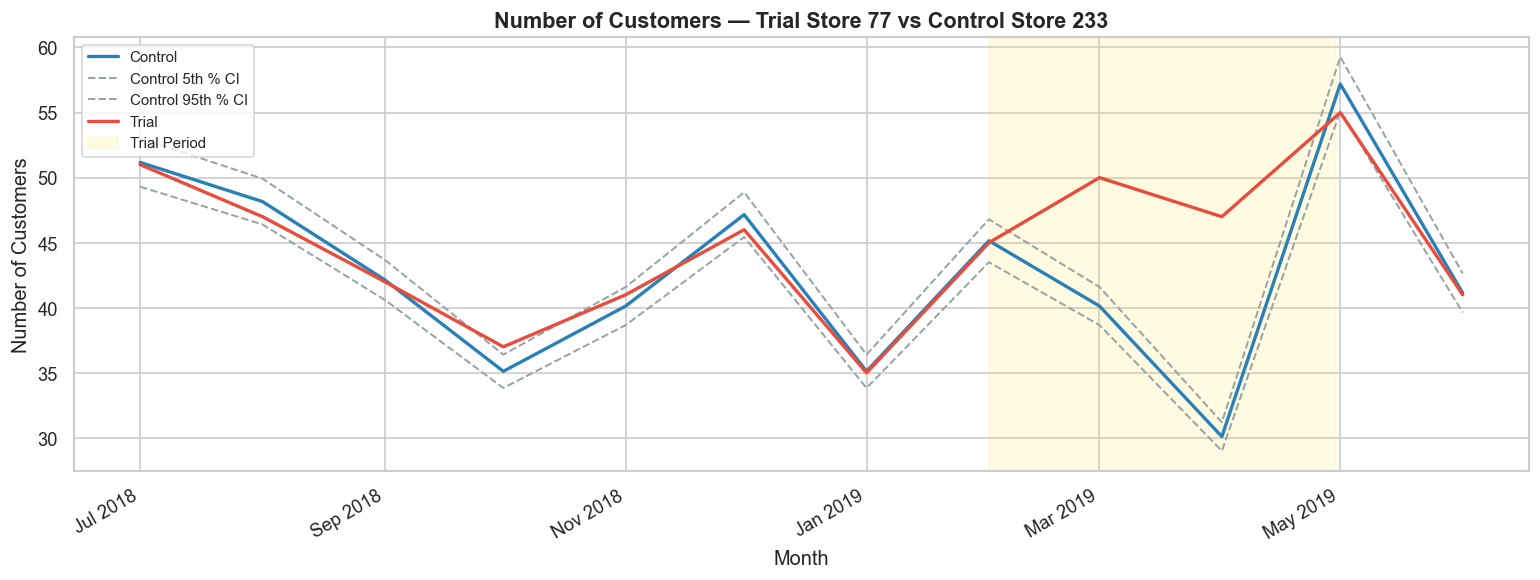

Figure saved: trial_assessment_store77_nCustomers.png


In [14]:
result_77_custs = assess_trial(
    trial_store   = trial_store_77,
    control_store = control_77,
    measure_df    = measure_over_time,
    metric        = 'nCustomers',
    metric_label  = 'Number of Customers',
    fig_prefix    = 'trial_assessment'
)

#### TRAIL STORE 86

#### 5.1 FIND CONTROL STORE FOR STORE 86

In [15]:
trial_store_86 = 86
control_86, scores_86 = get_control_store(trial_store_86, pre_trial_measures)

print(f' Best control store for Trial Store 86 → Store {control_86}')
print('\nTop 5 matching stores:')
print(scores_86.head())

✅ Best control store for Trial Store 86 → Store 155

Top 5 matching stores:
   Store1  Store2  scoreNSales  scoreNCust  finalScore
0      86     155     0.938423    0.971438    0.954930
1      86     109     0.894150    0.875555    0.884853
2      86     114     0.844751    0.901951    0.873351
3      86     138     0.859483    0.845350    0.852416
4      86     225     0.805183    0.857062    0.831122


#### 5.2 VISUAL PRE-TRAIL CHECK - STORE 86

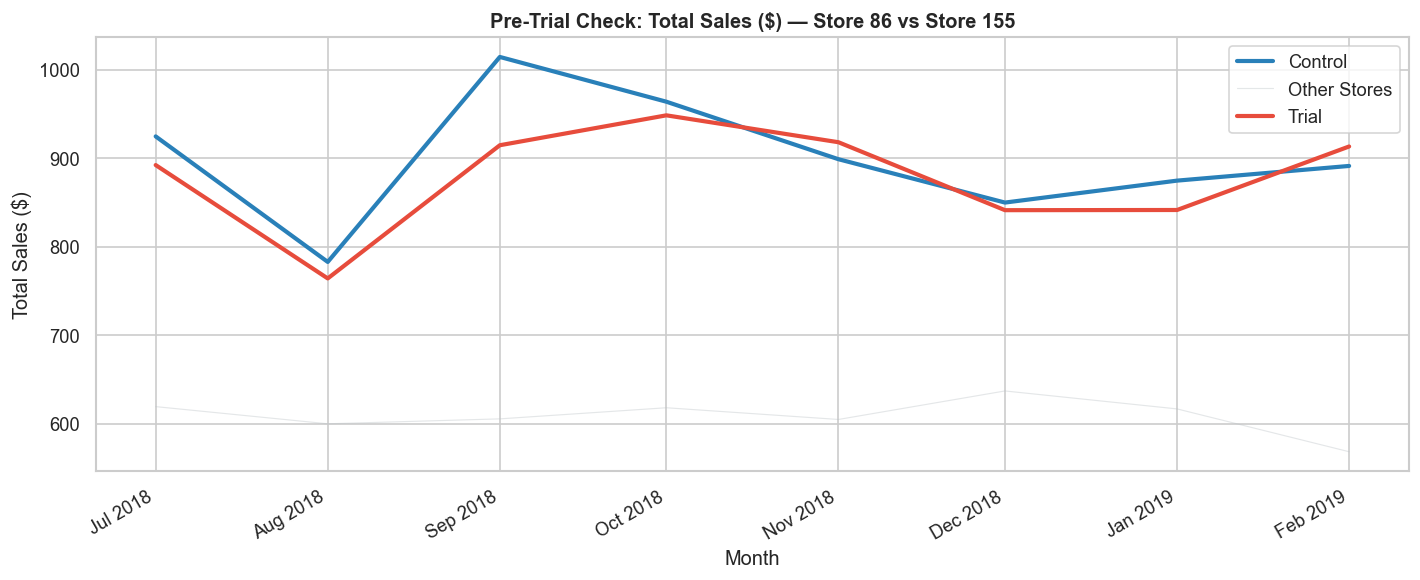

In [16]:
plot_pre_trial_check(trial_store_86, control_86, measure_over_time, 'totSales', 'Total Sales ($)')

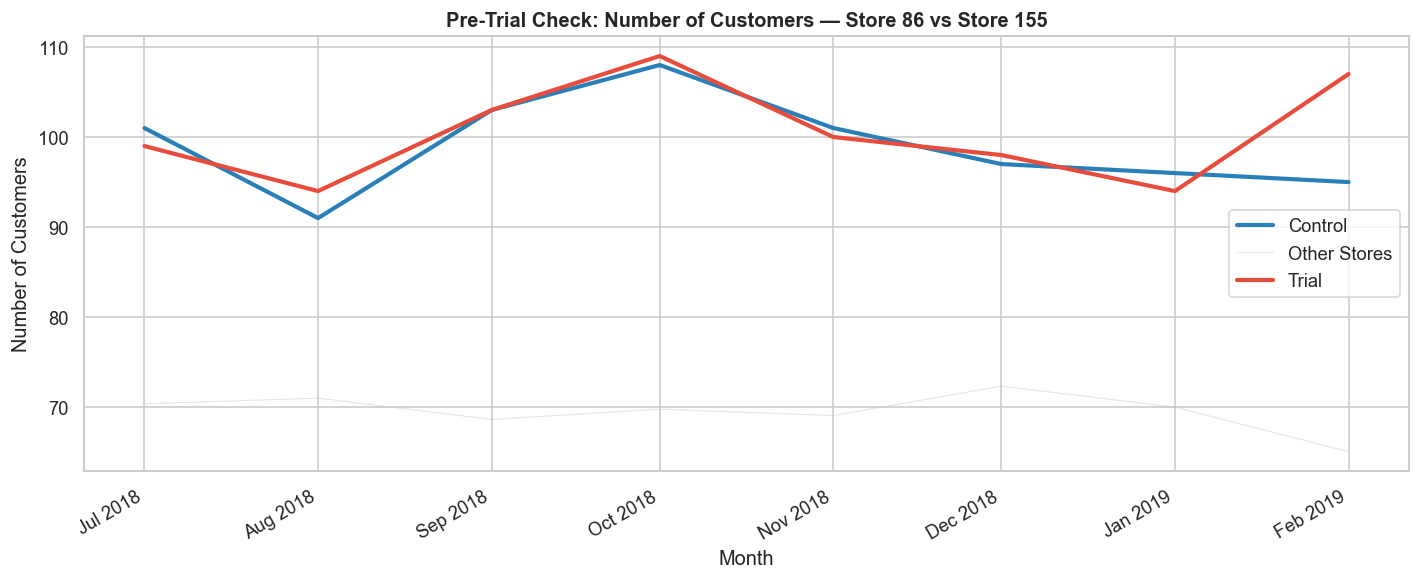

In [17]:
plot_pre_trial_check(trial_store_86, control_86, measure_over_time, 'nCustomers', 'Number of Customers')

#### TRAIL ASSESMENT - STORE 86 (TOTAL SALES)


════════════════════════════════════════════════════════════
  Trial Store 86  ←→  Control Store 155
  Metric: Total Sales ($)
  Scaling factor: 0.9701
  Pre-trial std dev of % diff: 0.0258
  T-critical (95%, df=7): 1.8946
────────────────────────────────────────────────────────────
  Month            % Diff    T-Value   Significant?
  201902           0.0563     2.1795          ✅ YES
  201903           0.3159    12.2269          ✅ YES
  201904           0.0353     1.3646           ❌ NO
════════════════════════════════════════════════════════════


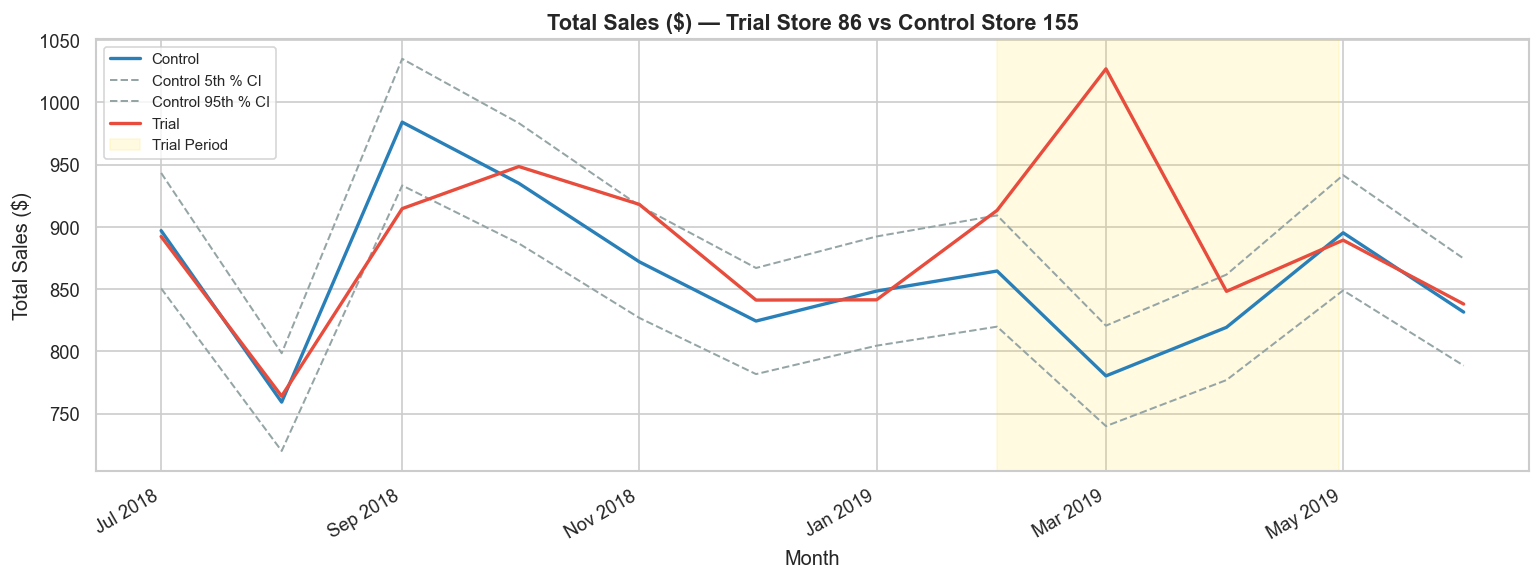

Figure saved: trial_assessment_store86_totSales.png


In [19]:
result_86_sales = assess_trial(
    trial_store   = trial_store_86,
    control_store = control_86,
    measure_df    = measure_over_time,
    metric        = 'totSales',
    metric_label  = 'Total Sales ($)',
    fig_prefix    = 'trial_assessment'
)

#### 5.4 TRAIL ASSESMENT - STORE 86 (NO. OF CUSTOMERS)


════════════════════════════════════════════════════════════
  Trial Store 86  ←→  Control Store 155
  Metric: Number of Customers
  Scaling factor: 1.0000
  Pre-trial std dev of % diff: 0.0107
  T-critical (95%, df=7): 1.8946
────────────────────────────────────────────────────────────
  Month            % Diff    T-Value   Significant?
  201902           0.1263    11.8191          ✅ YES
  201903           0.2234    20.9034          ✅ YES
  201904           0.0606     5.6708          ✅ YES
════════════════════════════════════════════════════════════


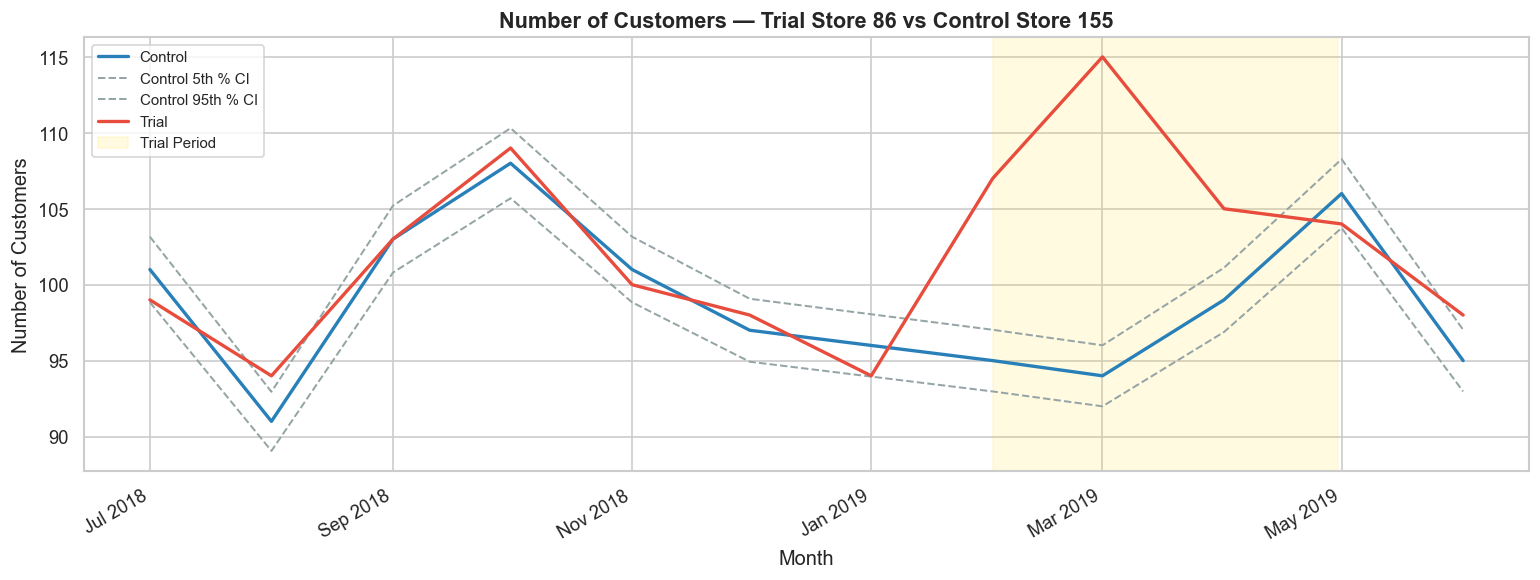

Figure saved: trial_assessment_store86_nCustomers.png


In [20]:
result_86_custs = assess_trial(
    trial_store   = trial_store_86,
    control_store = control_86,
    measure_df    = measure_over_time,
    metric        = 'nCustomers',
    metric_label  = 'Number of Customers',
    fig_prefix    = 'trial_assessment'
)

#### TRAIL STORE 88

#### 6.1 FIND CONTROL STORE FOR STORE 88

In [21]:
trial_store_88 = 88
control_88, scores_88 = get_control_store(trial_store_88, pre_trial_measures)

print(f'✅ Best control store for Trial Store 88 → Store {control_88}')
print('\nTop 5 matching stores:')
print(scores_88.head())

✅ Best control store for Trial Store 88 → Store 237

Top 5 matching stores:
   Store1  Store2  scoreNSales  scoreNCust  finalScore
0      88     237     0.654240    0.973663    0.813951
1      88     178     0.728884    0.884324    0.806604
2      88      69     0.594328    0.847398    0.720863
3      88     113     0.604013    0.826927    0.715470
4      88     201     0.702425    0.721250    0.711837


#### 6.2 VISUAL PRE - TRAIL CHECK -STORE 88

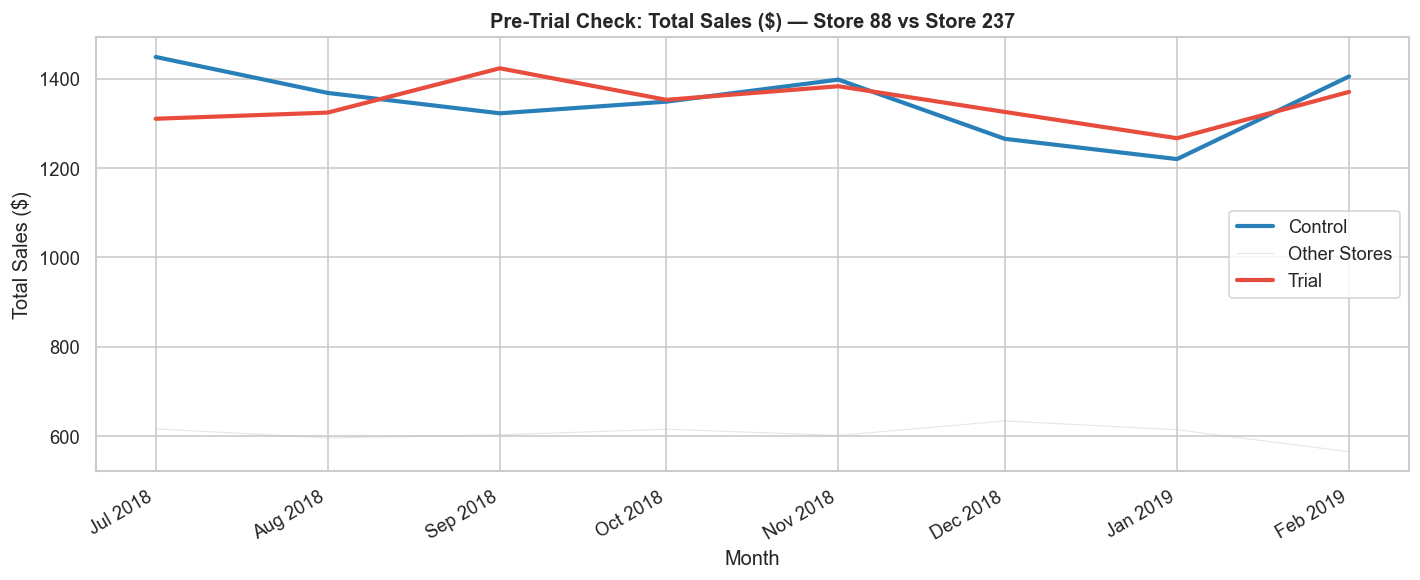

In [22]:
plot_pre_trial_check(trial_store_88, control_88, measure_over_time, 'totSales', 'Total Sales ($)')

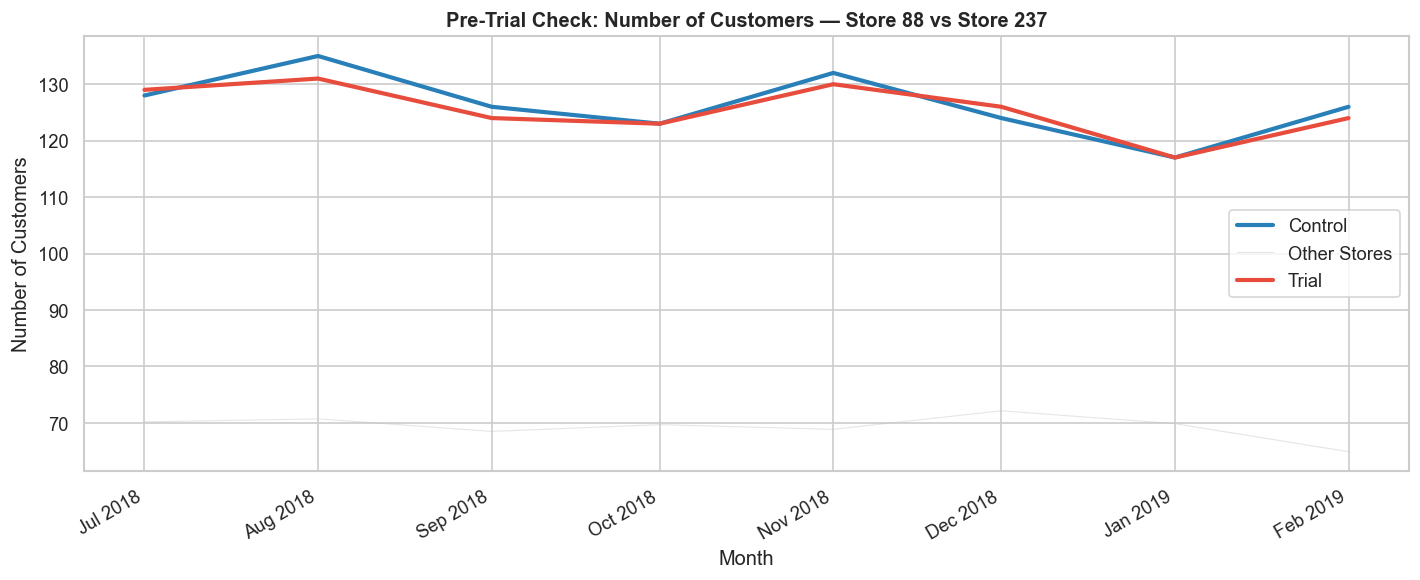

In [23]:
plot_pre_trial_check(trial_store_88, control_88, measure_over_time, 'nCustomers', 'Number of Customers')

#### 6.3 TRAIL ASSESMENT - STORE 88 (TOTAL SALES)


════════════════════════════════════════════════════════════
  Trial Store 88  ←→  Control Store 237
  Metric: Total Sales ($)
  Scaling factor: 1.0016
  Pre-trial std dev of % diff: 0.0335
  T-critical (95%, df=7): 1.8946
────────────────────────────────────────────────────────────
  Month            % Diff    T-Value   Significant?
  201902           0.0261     0.7813           ❌ NO
  201903           0.2207     6.5957          ✅ YES
  201904           0.1931     5.7685          ✅ YES
════════════════════════════════════════════════════════════


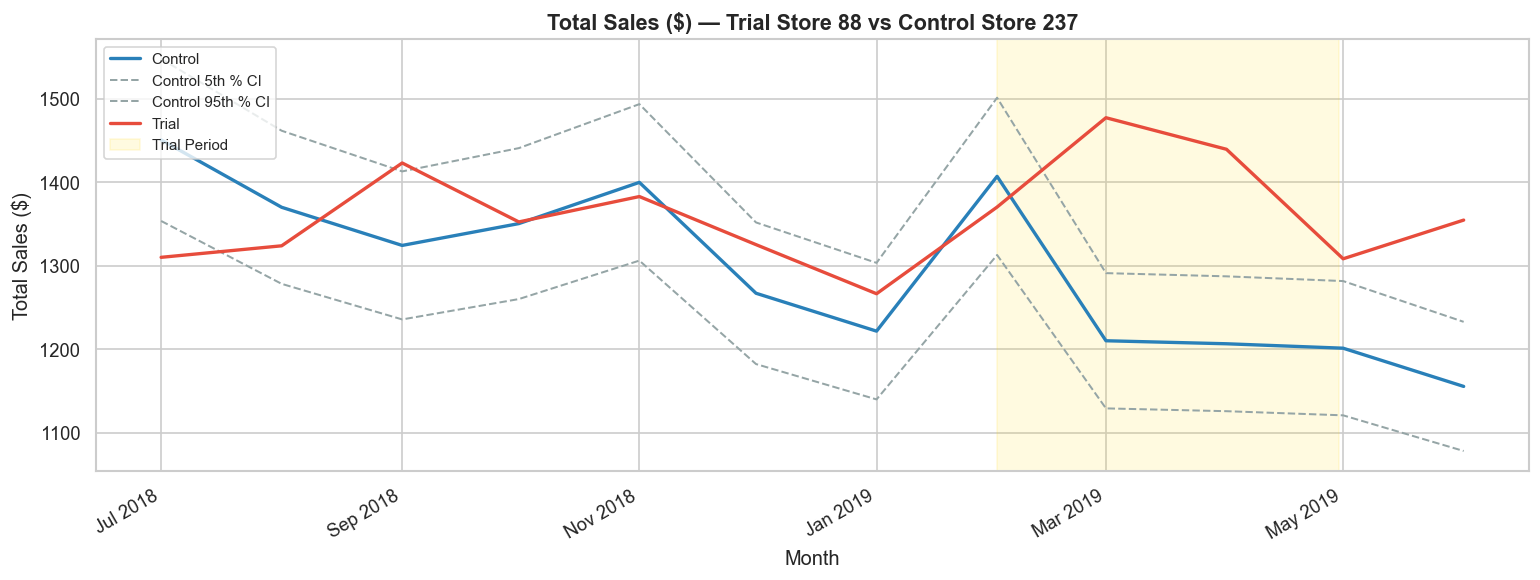

Figure saved: trial_assessment_store88_totSales.png


In [24]:
result_88_sales = assess_trial(
    trial_store   = trial_store_88,
    control_store = control_88,
    measure_df    = measure_over_time,
    metric        = 'totSales',
    metric_label  = 'Total Sales ($)',
    fig_prefix    = 'trial_assessment'
)

#### TRAIL ASSESMENT - STORE 88 (NO. OF CUSTOMERS)


════════════════════════════════════════════════════════════
  Trial Store 88  ←→  Control Store 237
  Metric: Number of Customers
  Scaling factor: 0.9944
  Pre-trial std dev of % diff: 0.0074
  T-critical (95%, df=7): 1.8946
────────────────────────────────────────────────────────────
  Month            % Diff    T-Value   Significant?
  201902           0.0103     1.3875           ❌ NO
  201903           0.1324    17.8737          ✅ YES
  201904           0.0727     9.8144          ✅ YES
════════════════════════════════════════════════════════════


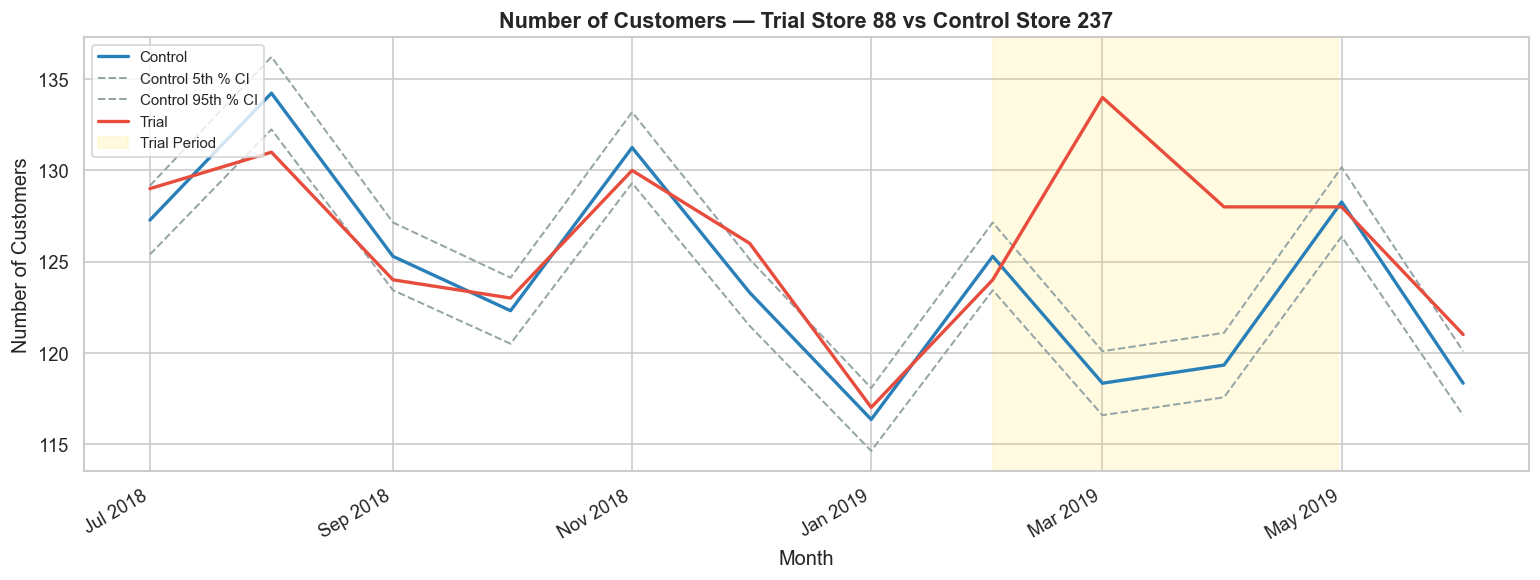

Figure saved: trial_assessment_store88_nCustomers.png


In [25]:
result_88_custs = assess_trial(
    trial_store   = trial_store_88,
    control_store = control_88,
    measure_df    = measure_over_time,
    metric        = 'nCustomers',
    metric_label  = 'Number of Customers',
    fig_prefix    = 'trial_assessment'
)

#### OVERALL DASHBOARD

In [26]:

def summarise(result_df, trial_store, metric_name):
    rows = []
    for _, row in result_df.iterrows():
        rows.append({
            'Trial Store'  : trial_store,
            'Metric'       : metric_name,
            'Month'        : str(int(row['YEARMONTH'])),
            '% Difference' : f"{row['pct_diff']*100:.1f}%",
            'T-Value'      : f"{row['t_value']:.2f}",
            'Significant?' : '✅ YES' if row['significant'] else '❌ NO'
        })
    return pd.DataFrame(rows)

summary = pd.concat([
    summarise(result_77_sales, 77, 'Total Sales'),
    summarise(result_77_custs, 77, 'Num Customers'),
    summarise(result_86_sales, 86, 'Total Sales'),
    summarise(result_86_custs, 86, 'Num Customers'),
    summarise(result_88_sales, 88, 'Total Sales'),
    summarise(result_88_custs, 88, 'Num Customers'),
], ignore_index=True)

print('═'*72)
print('  COMPLETE TRIAL RESULTS SUMMARY')
print('═'*72)
print(summary.to_string(index=False))
summary.to_csv('task2_trial_summary.csv', index=False)
print('\n✓ Summary saved as task2_trial_summary.csv')

════════════════════════════════════════════════════════════════════════
  COMPLETE TRIAL RESULTS SUMMARY
════════════════════════════════════════════════════════════════════════
 Trial Store        Metric  Month % Difference T-Value Significant?
          77   Total Sales 201902         5.9%    1.18         ❌ NO
          77   Total Sales 201903        36.7%    7.34        ✅ YES
          77   Total Sales 201904        62.3%   12.48        ✅ YES
          77 Num Customers 201902         0.3%    0.18         ❌ NO
          77 Num Customers 201903        24.6%   13.48        ✅ YES
          77 Num Customers 201904        56.1%   30.78        ✅ YES
          86   Total Sales 201902         5.6%    2.18        ✅ YES
          86   Total Sales 201903        31.6%   12.23        ✅ YES
          86   Total Sales 201904         3.5%    1.36         ❌ NO
          86 Num Customers 201902        12.6%   11.82        ✅ YES
          86 Num Customers 201903        22.3%   20.90        ✅ YES
     